In [19]:
import sys
from pathlib import Path
#print(Path.cwd().parent)

project_root = Path.cwd().parent
src_path = project_root / "src"

sys.path.append(str(src_path))

from movie_match.data.load_data import load_ratings
ratings = load_ratings("../data/raw/ratings.csv")

In [20]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [21]:
print("Rows:", len(ratings))
print("Users:", ratings["userId"].nunique())
print("Movies:", ratings["movieId"].nunique())

Rows: 25000095
Users: 162541
Movies: 59047


In [22]:
print(ratings.dtypes)
print("Check null values/n")
ratings.isnull().sum()

userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object
Check null values/n


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

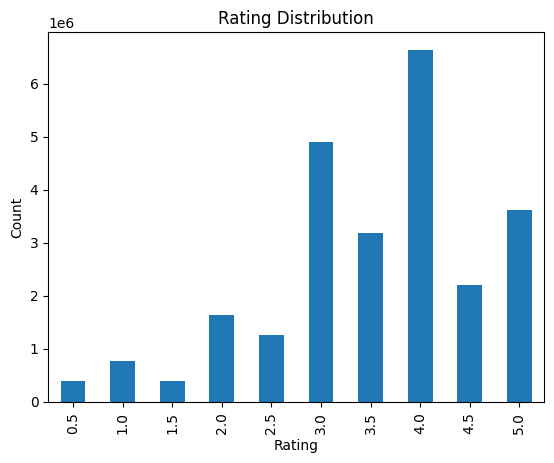

In [23]:
#print(ratings["rating"].value_counts().sort_index())

import matplotlib.pyplot as plt

ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.show()

In [24]:
user_interactions = ratings.groupby("userId").size()
user_interactions.describe()

count    162541.000000
mean        153.807932
std         268.047590
min          20.000000
25%          36.000000
50%          71.000000
75%         162.000000
max       32202.000000
dtype: float64

In [25]:
movie_interactions = ratings.groupby("movieId").size()
movie_interactions.describe()

count    59047.000000
mean       423.393144
std       2477.885821
min          1.000000
25%          2.000000
50%          6.000000
75%         36.000000
max      81491.000000
dtype: float64

In [26]:
import pandas as pd
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")
print(ratings["timestamp"].min())
print(ratings["timestamp"].max())

1995-01-09 11:46:49
2019-11-21 09:15:03


In [27]:
num_users = ratings["userId"].nunique()
num_movies = ratings["movieId"].nunique()
num_interactions = len(ratings)

possible_interactions = num_users * num_movies

sparsity = 1 - (num_interactions / possible_interactions)

print("Sparsity:", sparsity)

Sparsity: 0.9973951609474271


In [28]:
ratings["positive_interaction"] = ratings["rating"] >= 4
ratings["positive_interaction"].value_counts(normalize=True)

False    0.501889
True     0.498111
Name: positive_interaction, dtype: float64